**Imports and Data loading**

In [30]:
# pandas  --> used for reading and working with data tables
# numpy   --> used for numbers and calculations
# matplotlib --> used for creating charts and graphs
# seaborn --> makes charts look better, built on matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load the CSV file into a variable called 'df'
df = pd.read_csv('foodhub_order.csv')

print("Data loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Data loaded successfully!
Shape: 1898 rows, 9 columns


**Looking at the Data in the CSV file**

In [31]:
# .head() shows the first 5 rows by default
# We pass 10 to see the first 10 rows instead
# This gives us a quick look at what the data looks like
df.head(10)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3,20,24
6,1477894,157711,The Meatball Shop,Italian,6.07,Weekend,Not given,28,21
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3,33,30
8,1477174,121706,Anjappar Chettinad,Indian,16.44,Weekday,5,21,26
9,1477311,39705,Bukhara Grill,Indian,7.18,Weekday,5,29,26


**Understanding the structure of the data**

In [32]:
# .shape returns (number of rows, number of columns)
# This tells us how big our dataset is
print("Shape of the dataset:", df.shape)

# .info() gives us:
# - Column names
# - How many non-null (non-missing) values each column has
# - Data type of each column (int, float, object/string)
# This is important to spot any data type issues early
df.info()

Shape of the dataset: (1898, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   str    
 3   cuisine_type           1898 non-null   str    
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   str    
 6   rating                 1898 non-null   str    
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 133.6 KB


============================================================

In the ".head" when we look at the rating it has "Not given" for missing rating. This could give us problem late while doing analysis. We cannot aggregate the rating if it is str see above on ".info".

**Fixing the rating Column**

We need to:

  Step 1 - Replace "Not given" with NaN (NaN = Not a Number = Python's way of saying "missing value")
  
  Step 2 - Convert the column to a number type

==============================================================

In [33]:
# Replace "Not given" with NaN
df['rating'] = df['rating'].replace('Not given', np.nan)

# Convert the column from text to float (decimal number)
df['rating'] = df['rating'].astype(float)

# Calculate percentage of missing ratings
missing = df['rating'].isnull().sum()
total = len(df)
missing_pct = (missing / total) * 100

print("Data type of rating column now:", df['rating'].dtype)
print(f"Missing values in rating column: {missing} ({missing_pct:.0f}% of total orders)")

Data type of rating column now: float64
Missing values in rating column: 736 (39% of total orders)


**STATISTICAL SUMMARY**

In [34]:
# .describe() gives us key statistics for all numerical columns:
# .T at the end "transposes" the table (flips rows and columns)

df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
rating,1162.0,4.344234e+00,0.741478,3.00,4.00,5.00,5.000000e+00,5.00
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


**Checking for Missing Value**

In [35]:
# .isnull() check for missing value
# .sum() add those missing value

df.isnull().sum()

order_id                   0
customer_id                0
restaurant_name            0
cuisine_type               0
cost_of_the_order          0
day_of_the_week            0
rating                   736
food_preparation_time      0
delivery_time              0
dtype: int64

**Checking for Duplicate Rows**

In [36]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


**Univariate Analysis - Cuisine Type**

In [37]:
# counting the total cuisine type

print(df['cuisine_type'].value_counts())

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64


**Cuisine Type - Bar Chart**

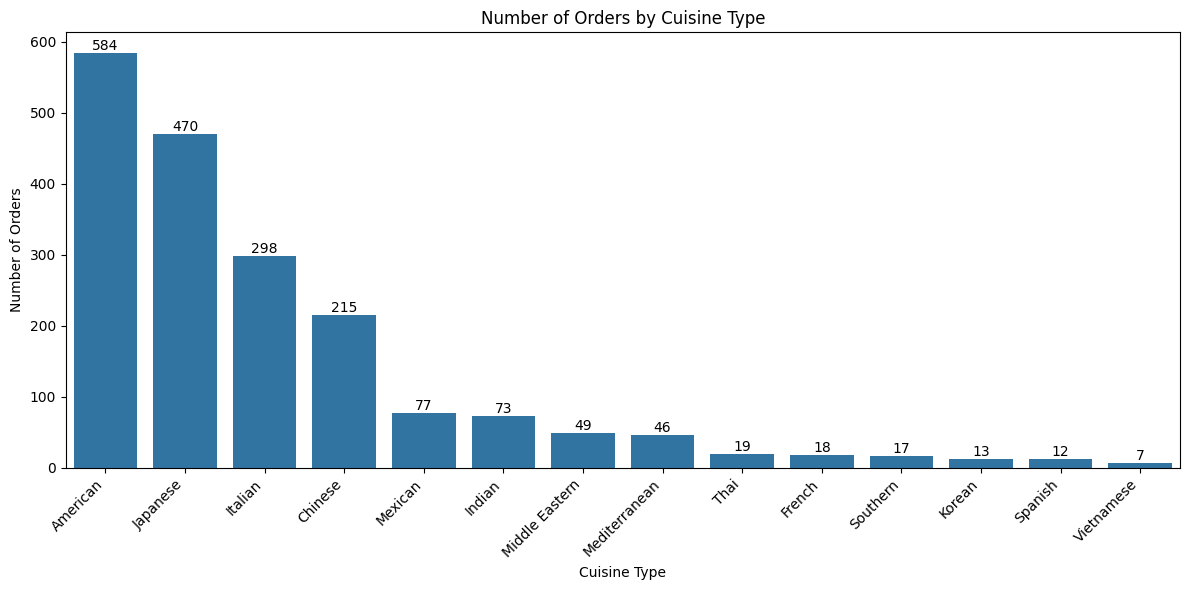

In [38]:
# countplot counts and plots the number of orders per cuisine type
# order= sorts the bars from highest to lowest
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='cuisine_type', 
                   order=df['cuisine_type'].value_counts().index)

# Add the exact count number on top of each bar
for container in ax.containers:
    ax.bar_label(container)

# Rotate x-axis labels so they don't overlap each other
plt.xticks(rotation=45, ha='right')

# Add clear labels and title
plt.title('Number of Orders by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**Univariate Analysis - Cost of Order**

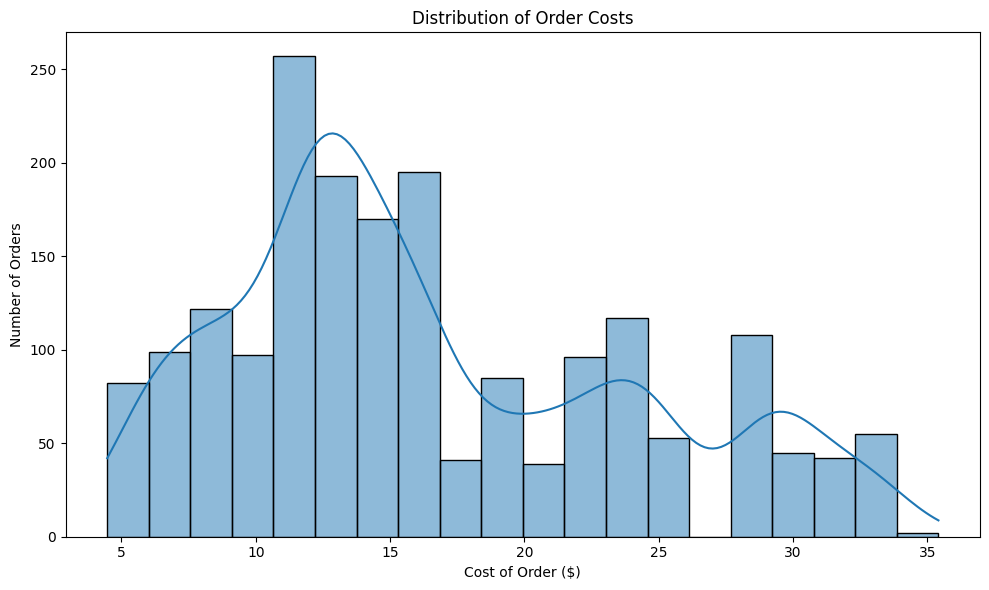

In [39]:
# A histogram shows us the distribution of order costs
plt.figure(figsize=(10, 6))
sns.histplot(df['cost_of_the_order'], bins=20, kde=True)
# bins=20 means we split the data into 20 groups
# kde=True adds a smooth curve on top showing the overall shape

plt.title('Distribution of Order Costs')
plt.xlabel('Cost of Order ($)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**Univariate Analysis - Delivery Time**

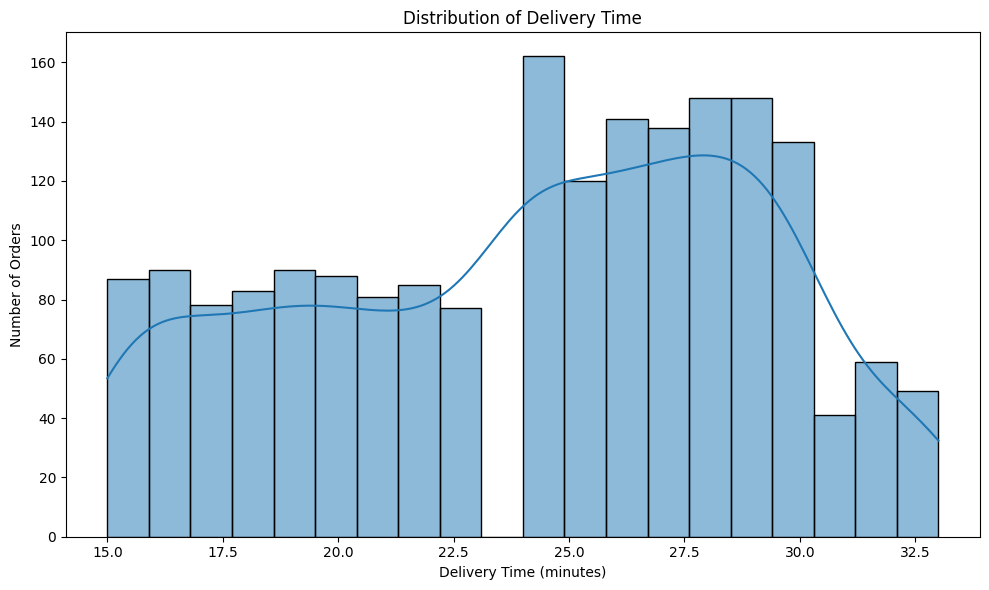

In [40]:
# Histogram to see how delivery times are distributed
plt.figure(figsize=(10, 6))
sns.histplot(df['delivery_time'], bins=20, kde=True)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**Univariate Analysis - Food prep time**

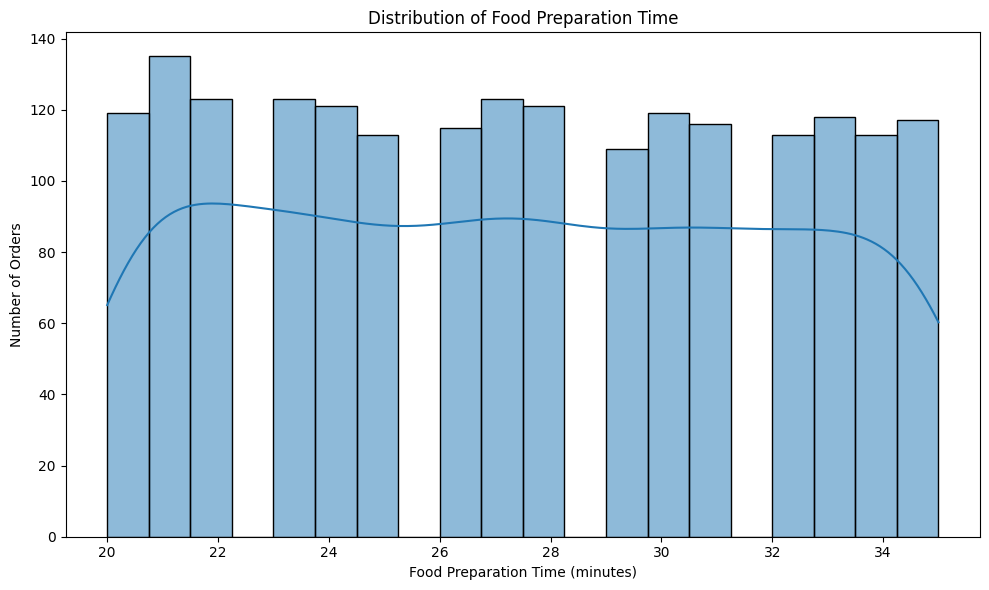

In [41]:

# Histogram to see how food preparation times are distributed
plt.figure(figsize=(10, 6))
sns.histplot(df['food_preparation_time'], bins=20, kde=True)

plt.title('Distribution of Food Preparation Time')
plt.xlabel('Food Preparation Time (minutes)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**Univariate Analysis - Rating**

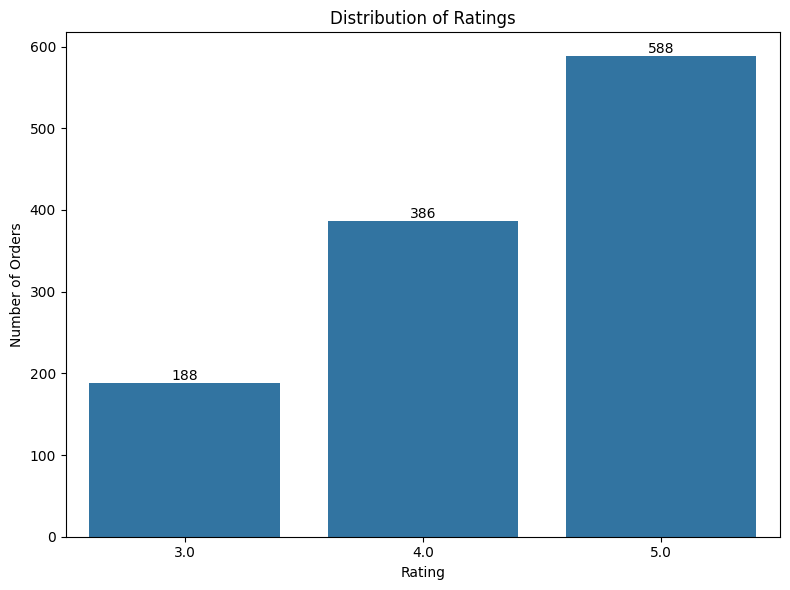

In [45]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='rating',order = [3.0, 4.0, 5.0])

# Add count on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**Univariate Analysis - Day of the Week**

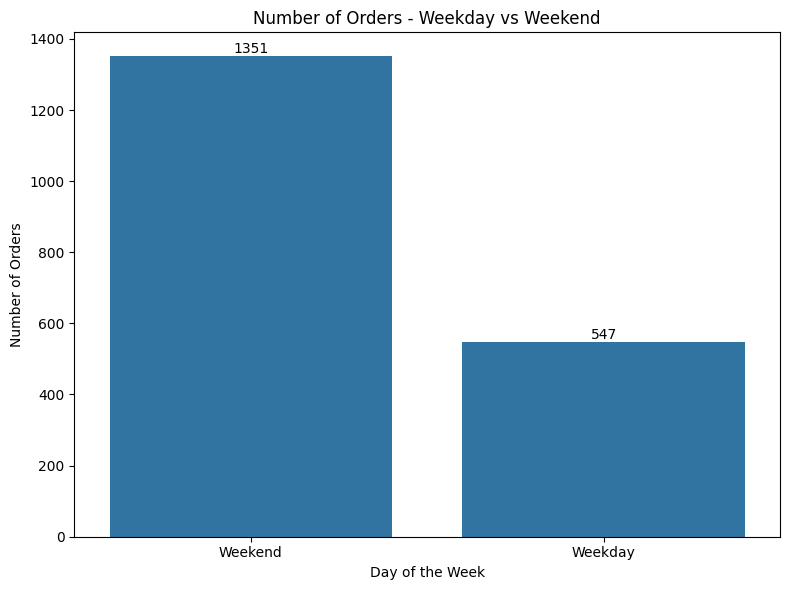

In [46]:

# countplot to compare number of orders on weekdays vs weekends
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='day_of_the_week')

# Add count on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Orders - Weekday vs Weekend')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [47]:
total = len(df)
weekend_count = (df['day_of_the_week'] == 'Weekend').sum()
weekday_count = (df['day_of_the_week'] == 'Weekday').sum()

#% for weekend / Week day
print(f'% Weekend : {weekend_count/total*100:.0f}%')
print(f'% Weekday : {weekday_count/total*100:.0f}%')

% Weekend : 71%
% Weekday : 29%


**Multivariate Analysis - Cost Vs Day of the Week**

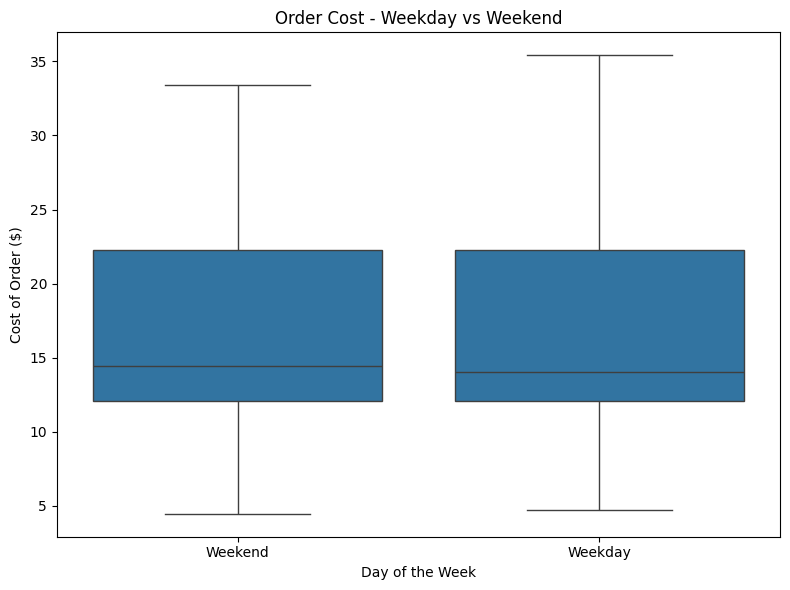

In [48]:

# boxplot compares the distribution of cost between weekday and weekend
# It shows median, spread, and outliers all in one chart
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='day_of_the_week', y='cost_of_the_order')

plt.title('Order Cost - Weekday vs Weekend')
plt.xlabel('Day of the Week')
plt.ylabel('Cost of Order ($)')

plt.tight_layout()
plt.show()

**Multivariate Analysis - Cost Vs Cuisine Type**

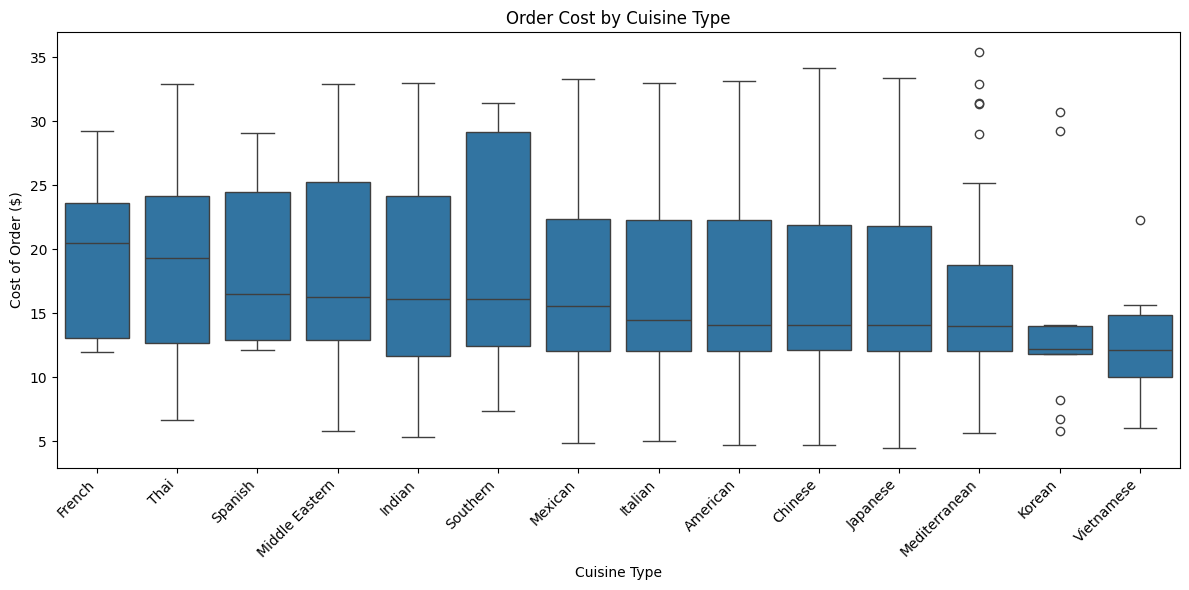

In [49]:

# boxplot to see if different cuisines cost more or less
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='cuisine_type', y='cost_of_the_order',
            order=df.groupby('cuisine_type')['cost_of_the_order']
            .median().sort_values(ascending=False).index)

plt.xticks(rotation=45, ha='right')
plt.title('Order Cost by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of Order ($)')

plt.tight_layout()
plt.show()

**Top 10 Restaurants by number of Orders**

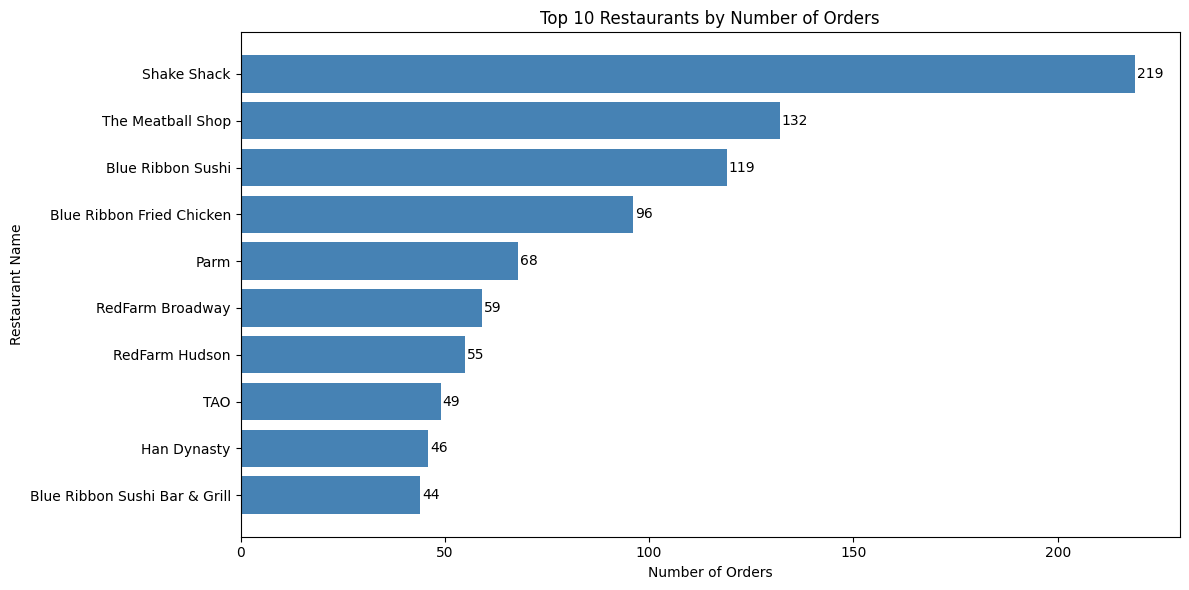

In [50]:
# head(10) keeps only the top 10
top_restaurants = df['restaurant_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_restaurants.index, top_restaurants.values, 
                color='steelblue')

# Add count at the end of each bar
for bar in bars:
    plt.text(bar.get_width() + 0.5,
             bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center')

plt.title('Top 10 Restaurants by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Restaurant Name')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

**Multivariate Analysis - Delivery Time Vs Day of the Week**

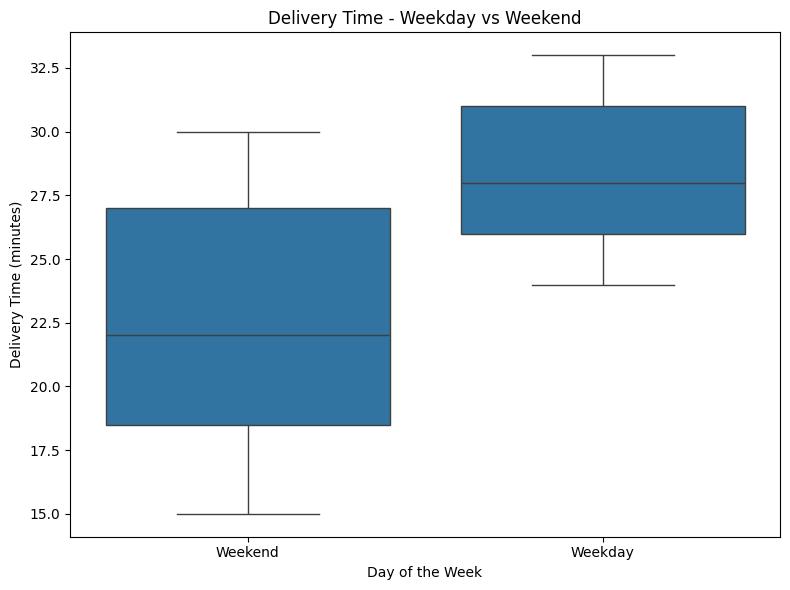

In [51]:

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='day_of_the_week', y='delivery_time')

plt.title('Delivery Time - Weekday vs Weekend')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')

plt.tight_layout()
plt.show()

**Multivariate Analysis - Rating Vs Delivery Time**

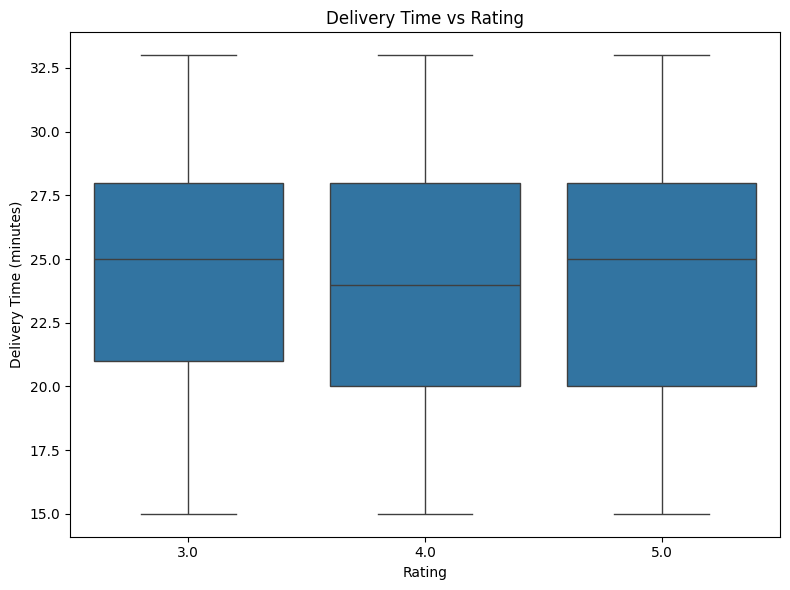

In [52]:

plt.figure(figsize=(8, 6))
sns.boxplot(data=df.dropna(subset=['rating']), 
            x='rating', y='delivery_time')

plt.title('Delivery Time vs Rating')
plt.xlabel('Rating')
plt.ylabel('Delivery Time (minutes)')

plt.tight_layout()
plt.show()

**Multivariate Analysis - Rating Vs Food Prep Time**

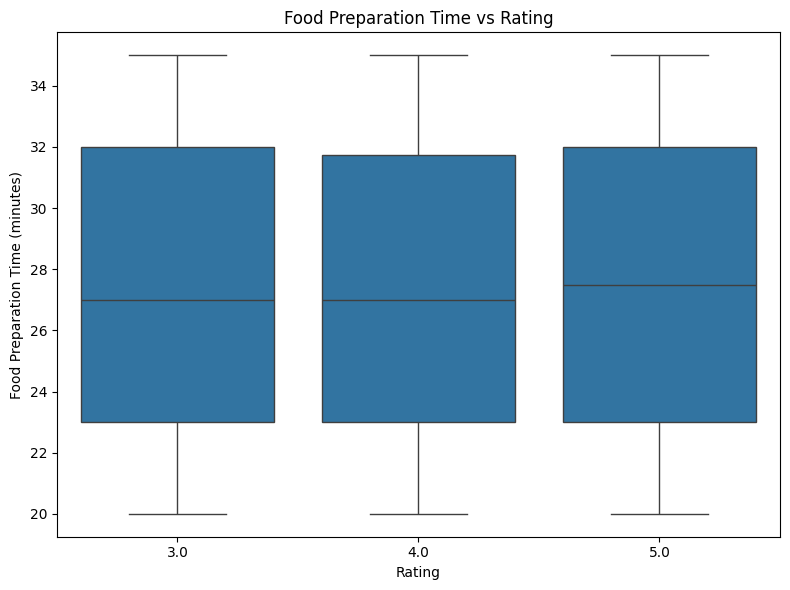

In [53]:

plt.figure(figsize=(8, 6))
sns.boxplot(data=df.dropna(subset=['rating']), 
            x='rating', y='food_preparation_time')

plt.title('Food Preparation Time vs Rating')
plt.xlabel('Rating')
plt.ylabel('Food Preparation Time (minutes)')

plt.tight_layout()
plt.show()

**Total Order Time (Food Prep + Delivery)**

In [54]:

# Adding total prep + delivery & putting it in Tot_time New COlumn
df['total_time'] = df['food_preparation_time'] + df['delivery_time']


print("Total Order Time Stat:")
print(f"Minimum : {df['total_time'].min()} minutes")
print(f"Maximum : {df['total_time'].max()} minutes")
print(f"Average : {df['total_time'].mean():.2f} minutes")
print(f"Median  : {df['total_time'].median()} minutes")

# How many orders took more than 60 minutes total?
over_60 = (df['total_time'] > 60).sum()
print(f"\nOrders taking more than 60 minutes: {over_60}")
print(f"That is {(over_60/len(df)*100):.1f}% of all orders")

Total Order Time Stat:
Minimum : 35 minutes
Maximum : 68 minutes
Average : 51.53 minutes
Median  : 52.0 minutes

Orders taking more than 60 minutes: 200
That is 10.5% of all orders


**Histogram - Total Time**

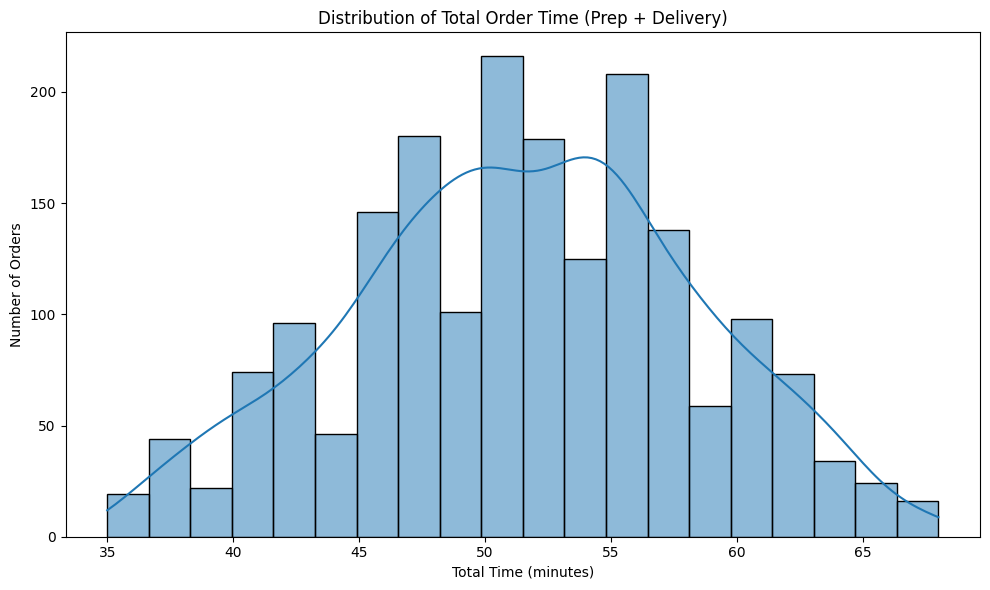

In [55]:

plt.figure(figsize=(10, 6))
sns.histplot(df['total_time'], bins=20, kde=True)

plt.title('Distribution of Total Order Time (Prep + Delivery)')
plt.xlabel('Total Time (minutes)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [56]:
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
total = len(df)
over_60  = (df['total_time'] > 60).sum()

print(f'Orders over 60 mins: {over_60} ({over_60/total*100:.0f}%)')    

Orders over 60 mins: 200 (11%)


**Revenue Analysis**

Orders by cost bracket:
cost_bracket
Low ($0-10)        394
Medium ($10-20)    949
High ($20-35)      554
Name: count, dtype: int64


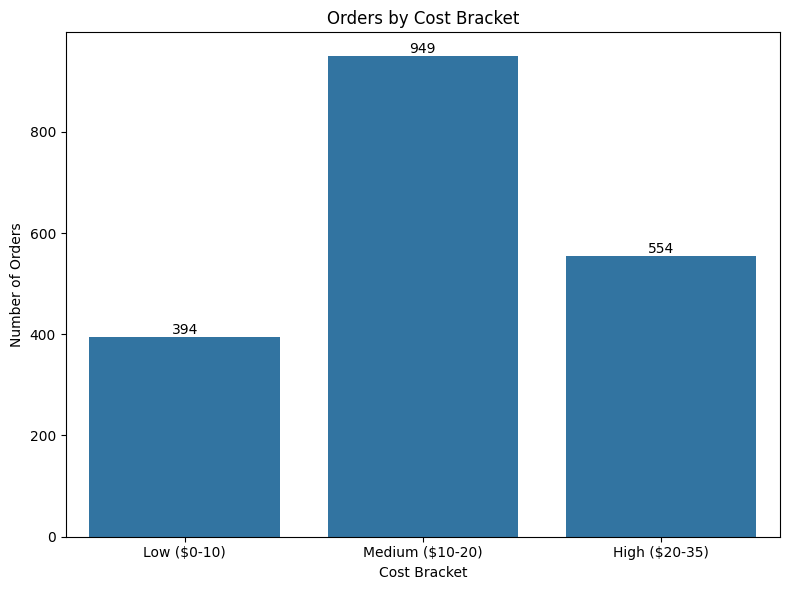

In [57]:
# Analysis FoodHub margin on each order. It says 15% on orders above $20
# and 25% on orders $20 and below 

# Seperating orders into cost brackets
df['cost_bracket'] = pd.cut(df['cost_of_the_order'],
                             bins=[0, 10, 20, 35],
                             labels=['Low ($0-10)', 
                                     'Medium ($10-20)', 
                                     'High ($20-35)'])

# Count orders in each bracket
cost_counts = df['cost_bracket'].value_counts().sort_index()
print("Orders by cost bracket:")
print(cost_counts)

# Visualize
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='cost_bracket',
                   order=['Low ($0-10)', 'Medium ($10-20)', 'High ($20-35)'])

for container in ax.containers:
    ax.bar_label(container)

plt.title('Orders by Cost Bracket')
plt.xlabel('Cost Bracket')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**Conclusions & Recommendation :**

In [58]:
print("""
CONCLUSIONS:
============
Total Orders          - 1898
Total Cuisines        - 14
Duplicate Records     - None
Missing Ratings       - 736 Orders (39%) have no rating

Top Cuisines          - American (584) & Japanese (470)
                        representing 56% of all Orders
Order Cost            - $11 to $17 with Average = $16.50
Weekend Orders        - 1351 (71%) vs Weekday 547 (29%)
Avg Delivery Time     - 24 minutes
Avg Prep Time         - 27 minutes
Avg Total Order Time  - 51.53 minutes
Orders over 60 mins   - 200 orders (10.5%)
Customer Satisfaction - 88% of rated orders gave 4 or 5

RECOMMENDATIONS:
================
Fix Rating Gap     - 39% of our data remains unrated and uncategorized. 
                        Investigate this gap and implement a strategy to capture the missing information.

Weekend Focus      - 71% orders are on weekends.
                        Focus more delivery staff on weekends.

Slow Orders        - 200 orders (11%) exceeded 60 minutes.
                        Investigate and try to bring it below 60 mins.

Top Cuisines       - Expand American & Japanese restaurant partners
                        as they drive majority of orders.

Rating Drivers     - Speed does not impact ratings.
                        Look into another aspect & survey with customers
""")


CONCLUSIONS:
Total Orders          - 1898
Total Cuisines        - 14
Duplicate Records     - None
Missing Ratings       - 736 Orders (39%) have no rating

Top Cuisines          - American (584) & Japanese (470)
                        representing 56% of all Orders
Order Cost            - $11 to $17 with Average = $16.50
Weekend Orders        - 1351 (71%) vs Weekday 547 (29%)
Avg Delivery Time     - 24 minutes
Avg Prep Time         - 27 minutes
Avg Total Order Time  - 51.53 minutes
Orders over 60 mins   - 200 orders (10.5%)
Customer Satisfaction - 88% of rated orders gave 4 or 5

RECOMMENDATIONS:
Fix Rating Gap     - 39% of our data remains unrated and uncategorized. 
                        Investigate this gap and implement a strategy to capture the missing information.

Weekend Focus      - 71% orders are on weekends.
                        Focus more delivery staff on weekends.

Slow Orders        - 200 orders (11%) exceeded 60 minutes.
                        Investigate and try